In [2]:
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
import matplotlib.pyplot as plt

In [3]:
valor_l_c = 5
grid = np.zeros((valor_l_c,valor_l_c))


for i in range(valor_l_c):
    for j in range(valor_l_c):
        grid[i,j] = np.random.choice([0,1])
# grid[0,1] = 1
# grid[3,0] = 1
# grid[2,1] = 1
# grid[3,4] = 1
# grid[2,4] = 1
# grid[2,3] = 1
# grid[4,0] = 1
# grid[4,0] = 1
# grid[4,2] = 1
print(grid)

origem = (0, 0)
destino = (4, 4)


[[0. 1. 0. 1. 1.]
 [1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 1.]
 [1. 1. 0. 1. 1.]]


In [4]:
vizinhos = {}
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        vizinho_viaveis = []
        # print(f"Vizinhos de ({i}, {j}):")
        cima = (i-1, j)
        baixo = (i+1, j)
        esquerda = (i, j-1)
        direita = (i, j+1)
        vizinho= [cima, baixo, esquerda, direita]
        for v in vizinho:
            # print(v[0], v[1])
            if v[0] >=0 and v[0] < grid.shape[0] and v[1] >= 0 and v[1] < grid.shape[1]:
                vizinho_viaveis.append(v)               
        vizinhos[(i, j)] = vizinho_viaveis

for k in vizinhos:
    print(k, vizinhos[k])

(0, 0) [(1, 0), (0, 1)]
(0, 1) [(1, 1), (0, 0), (0, 2)]
(0, 2) [(1, 2), (0, 1), (0, 3)]
(0, 3) [(1, 3), (0, 2), (0, 4)]
(0, 4) [(1, 4), (0, 3)]
(1, 0) [(0, 0), (2, 0), (1, 1)]
(1, 1) [(0, 1), (2, 1), (1, 0), (1, 2)]
(1, 2) [(0, 2), (2, 2), (1, 1), (1, 3)]
(1, 3) [(0, 3), (2, 3), (1, 2), (1, 4)]
(1, 4) [(0, 4), (2, 4), (1, 3)]
(2, 0) [(1, 0), (3, 0), (2, 1)]
(2, 1) [(1, 1), (3, 1), (2, 0), (2, 2)]
(2, 2) [(1, 2), (3, 2), (2, 1), (2, 3)]
(2, 3) [(1, 3), (3, 3), (2, 2), (2, 4)]
(2, 4) [(1, 4), (3, 4), (2, 3)]
(3, 0) [(2, 0), (4, 0), (3, 1)]
(3, 1) [(2, 1), (4, 1), (3, 0), (3, 2)]
(3, 2) [(2, 2), (4, 2), (3, 1), (3, 3)]
(3, 3) [(2, 3), (4, 3), (3, 2), (3, 4)]
(3, 4) [(2, 4), (4, 4), (3, 3)]
(4, 0) [(3, 0), (4, 1)]
(4, 1) [(3, 1), (4, 0), (4, 2)]
(4, 2) [(3, 2), (4, 1), (4, 3)]
(4, 3) [(3, 3), (4, 2), (4, 4)]
(4, 4) [(3, 4), (4, 3)]


In [5]:
for l,m in vizinhos[0,0]:
    print(l,m)

1 0
0 1


In [6]:
# criar os arcos do grafo
custo_passo = 1
arcos = []
arcos_custo = {}
keys = list(vizinhos.keys())
for i,(j,k) in enumerate(vizinhos.items()):
    # print(i, j, k)
    for jk in k:
        # print(f"Arco: {j} -> {jk}")
        
        soma = grid[jk[0], jk[1]] + grid[j[0], j[1]] + custo_passo
        arcos_custo[(j, jk)] = soma
        arcos.append((j, jk))

In [7]:
grid

array([[0., 1., 0., 1., 1.],
       [1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 1.],
       [1., 1., 0., 1., 1.]])

In [8]:
arcos_custo[(0,0),(0,1)]

np.float64(2.0)

In [9]:
arcos

[((0, 0), (1, 0)),
 ((0, 0), (0, 1)),
 ((0, 1), (1, 1)),
 ((0, 1), (0, 0)),
 ((0, 1), (0, 2)),
 ((0, 2), (1, 2)),
 ((0, 2), (0, 1)),
 ((0, 2), (0, 3)),
 ((0, 3), (1, 3)),
 ((0, 3), (0, 2)),
 ((0, 3), (0, 4)),
 ((0, 4), (1, 4)),
 ((0, 4), (0, 3)),
 ((1, 0), (0, 0)),
 ((1, 0), (2, 0)),
 ((1, 0), (1, 1)),
 ((1, 1), (0, 1)),
 ((1, 1), (2, 1)),
 ((1, 1), (1, 0)),
 ((1, 1), (1, 2)),
 ((1, 2), (0, 2)),
 ((1, 2), (2, 2)),
 ((1, 2), (1, 1)),
 ((1, 2), (1, 3)),
 ((1, 3), (0, 3)),
 ((1, 3), (2, 3)),
 ((1, 3), (1, 2)),
 ((1, 3), (1, 4)),
 ((1, 4), (0, 4)),
 ((1, 4), (2, 4)),
 ((1, 4), (1, 3)),
 ((2, 0), (1, 0)),
 ((2, 0), (3, 0)),
 ((2, 0), (2, 1)),
 ((2, 1), (1, 1)),
 ((2, 1), (3, 1)),
 ((2, 1), (2, 0)),
 ((2, 1), (2, 2)),
 ((2, 2), (1, 2)),
 ((2, 2), (3, 2)),
 ((2, 2), (2, 1)),
 ((2, 2), (2, 3)),
 ((2, 3), (1, 3)),
 ((2, 3), (3, 3)),
 ((2, 3), (2, 2)),
 ((2, 3), (2, 4)),
 ((2, 4), (1, 4)),
 ((2, 4), (3, 4)),
 ((2, 4), (2, 3)),
 ((3, 0), (2, 0)),
 ((3, 0), (4, 0)),
 ((3, 0), (3, 1)),
 ((3, 1), (2

In [10]:
matriz_soma = {}
for k in keys:
    matriz_soma[k] = 0

In [11]:
matriz_soma[(0,0)]= -1
matriz_soma[(4,4)]= 1
matriz_soma

{(0, 0): -1,
 (0, 1): 0,
 (0, 2): 0,
 (0, 3): 0,
 (0, 4): 0,
 (1, 0): 0,
 (1, 1): 0,
 (1, 2): 0,
 (1, 3): 0,
 (1, 4): 0,
 (2, 0): 0,
 (2, 1): 0,
 (2, 2): 0,
 (2, 3): 0,
 (2, 4): 0,
 (3, 0): 0,
 (3, 1): 0,
 (3, 2): 0,
 (3, 3): 0,
 (3, 4): 0,
 (4, 0): 0,
 (4, 1): 0,
 (4, 2): 0,
 (4, 3): 0,
 (4, 4): 1}

In [12]:
keys

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [13]:
model = pyo.ConcreteModel()

model.k = pyo.Set(initialize=keys)
model.arcos_key = pyo.Set(initialize=list(arcos_custo.keys()))
model.arcos_custo = pyo.Param(model.arcos_key, initialize=arcos_custo)
model.matriz_s = pyo.Param(model.k, initialize=matriz_soma)
model.x = pyo.Var(model.arcos_key, domain=pyo.Binary)

In [14]:
model.pprint()

2 Set Declarations
    arcos_key : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     4 :    Any :   80 : {(0, 0, 1, 0), (0, 0, 0, 1), (0, 1, 1, 1), (0, 1, 0, 0), (0, 1, 0, 2), (0, 2, 1, 2), (0, 2, 0, 1), (0, 2, 0, 3), (0, 3, 1, 3), (0, 3, 0, 2), (0, 3, 0, 4), (0, 4, 1, 4), (0, 4, 0, 3), (1, 0, 0, 0), (1, 0, 2, 0), (1, 0, 1, 1), (1, 1, 0, 1), (1, 1, 2, 1), (1, 1, 1, 0), (1, 1, 1, 2), (1, 2, 0, 2), (1, 2, 2, 2), (1, 2, 1, 1), (1, 2, 1, 3), (1, 3, 0, 3), (1, 3, 2, 3), (1, 3, 1, 2), (1, 3, 1, 4), (1, 4, 0, 4), (1, 4, 2, 4), (1, 4, 1, 3), (2, 0, 1, 0), (2, 0, 3, 0), (2, 0, 2, 1), (2, 1, 1, 1), (2, 1, 3, 1), (2, 1, 2, 0), (2, 1, 2, 2), (2, 2, 1, 2), (2, 2, 3, 2), (2, 2, 2, 1), (2, 2, 2, 3), (2, 3, 1, 3), (2, 3, 3, 3), (2, 3, 2, 2), (2, 3, 2, 4), (2, 4, 1, 4), (2, 4, 3, 4), (2, 4, 2, 3), (3, 0, 2, 0), (3, 0, 4, 0), (3, 0, 3, 1), (3, 1, 2, 1), (3, 1, 4, 1), (3, 1, 3, 0), (3, 1, 3, 2), (3, 2, 2, 2), (3, 2, 4, 2), (3, 2, 3, 1), (3, 2, 3, 3), 

In [15]:
model.matriz_s[0,0]

-1

In [16]:
for (i,j,k,l) in model.arcos_key.value:
    print((i,j),(k,l))

retrieve the values in a finite set.  (deprecated in 5.7) (called from
C:\Users\Pichau\AppData\Local\Temp\ipykernel_19596\3084306409.py:1)
(1, 2) (1, 1)
(4, 0) (3, 0)
(1, 3) (2, 3)
(3, 0) (3, 1)
(2, 1) (1, 1)
(0, 3) (1, 3)
(4, 4) (3, 4)
(1, 3) (1, 4)
(4, 4) (4, 3)
(2, 1) (3, 1)
(2, 3) (3, 3)
(1, 2) (1, 3)
(4, 0) (4, 1)
(0, 1) (0, 0)
(3, 3) (3, 2)
(3, 2) (3, 1)
(0, 2) (0, 1)
(0, 2) (1, 2)
(3, 0) (2, 0)
(4, 3) (3, 3)
(4, 3) (4, 2)
(3, 2) (2, 2)
(2, 2) (2, 1)
(3, 3) (3, 4)
(1, 1) (0, 1)
(2, 4) (2, 3)
(3, 0) (4, 0)
(3, 2) (3, 3)
(3, 2) (4, 2)
(0, 2) (0, 3)
(4, 3) (4, 4)
(2, 2) (2, 3)
(0, 4) (0, 3)
(3, 4) (4, 4)
(2, 3) (1, 3)
(3, 3) (2, 3)
(1, 4) (0, 4)
(1, 4) (1, 3)
(0, 1) (1, 1)
(1, 1) (1, 0)
(3, 3) (4, 3)
(1, 4) (2, 4)
(0, 1) (0, 2)
(2, 2) (1, 2)
(2, 4) (1, 4)
(3, 1) (3, 0)
(2, 2) (3, 2)
(1, 1) (1, 2)
(2, 4) (3, 4)
(3, 4) (2, 4)
(3, 4) (3, 3)
(4, 1) (4, 0)
(3, 1) (3, 2)
(0, 4) (1, 4)
(4, 2) (3, 2)
(4, 2) (4, 1)
(4, 1) (4, 2)
(4, 2) (4, 3)
(0, 3) (0, 2)
(3, 1) (2, 1)
(2, 1) (2, 0)
(1, 0) 

In [17]:
#Função objetivo

def func_obj(model):
    return sum(model.arcos_custo[a] * model.x[a] for a in model.arcos_key)
model.obj = pyo.Objective(rule=func_obj, sense=pyo.minimize)

In [18]:
for i,j in model.k:
    print((i,j))

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


In [19]:
# Restrição balanço

def func_balanco(model,i,j):
    #tudo que entra para cada i-J menos tudo que sai de cada J tem que ser igual a matriz
    entra = sum(model.x[l,m,i,j] for l,m in vizinhos[i,j])
    sai = sum(model.x[i,j,l,m,] for l,m in vizinhos[i,j])
    return entra-sai == model.matriz_s[i,j]

model.balanco = pyo.Constraint(model.k, rule=func_balanco)

In [20]:
opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
res = opt.solve(model)

In [21]:
valores = []
for s in model.x:
   
    print(s,":",pyo.value(model.x[s]))
valores = [s for s in model.x if pyo.value(model.x[s])>0]

(0, 0, 1, 0) : 0.0
(0, 0, 0, 1) : 1.0
(0, 1, 1, 1) : -0.0
(0, 1, 0, 0) : -0.0
(0, 1, 0, 2) : 1.0
(0, 2, 1, 2) : 1.0
(0, 2, 0, 1) : -0.0
(0, 2, 0, 3) : -0.0
(0, 3, 1, 3) : -0.0
(0, 3, 0, 2) : -0.0
(0, 3, 0, 4) : -0.0
(0, 4, 1, 4) : -0.0
(0, 4, 0, 3) : -0.0
(1, 0, 0, 0) : -0.0
(1, 0, 2, 0) : 0.0
(1, 0, 1, 1) : 0.0
(1, 1, 0, 1) : -0.0
(1, 1, 2, 1) : -0.0
(1, 1, 1, 0) : -0.0
(1, 1, 1, 2) : -0.0
(1, 2, 0, 2) : -0.0
(1, 2, 2, 2) : 1.0
(1, 2, 1, 1) : -0.0
(1, 2, 1, 3) : 0.0
(1, 3, 0, 3) : -0.0
(1, 3, 2, 3) : -0.0
(1, 3, 1, 2) : -0.0
(1, 3, 1, 4) : -0.0
(1, 4, 0, 4) : 0.0
(1, 4, 2, 4) : -0.0
(1, 4, 1, 3) : -0.0
(2, 0, 1, 0) : -0.0
(2, 0, 3, 0) : -0.0
(2, 0, 2, 1) : -0.0
(2, 1, 1, 1) : -0.0
(2, 1, 3, 1) : -0.0
(2, 1, 2, 0) : -0.0
(2, 1, 2, 2) : -0.0
(2, 2, 1, 2) : -0.0
(2, 2, 3, 2) : -0.0
(2, 2, 2, 1) : -0.0
(2, 2, 2, 3) : 1.0
(2, 3, 1, 3) : -0.0
(2, 3, 3, 3) : 1.0
(2, 3, 2, 2) : -0.0
(2, 3, 2, 4) : -0.0
(2, 4, 1, 4) : -0.0
(2, 4, 3, 4) : 0.0
(2, 4, 2, 3) : -0.0
(3, 0, 2, 0) : -0.0
(3, 0, 4, 0)

In [22]:
for a,b,c,d in valores:
    print(a,b,c,d)

0 0 0 1
0 1 0 2
0 2 1 2
1 2 2 2
2 2 2 3
2 3 3 3
3 3 4 3
4 3 4 4


In [23]:
grid

array([[0., 1., 0., 1., 1.],
       [1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 1.],
       [1., 1., 0., 1., 1.]])

In [24]:
grid

array([[0., 1., 0., 1., 1.],
       [1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 1.],
       [1., 1., 0., 1., 1.]])

[[0. 1. 0. 1. 1.]
 [1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 1.]
 [1. 1. 0. 1. 1.]]
(0, 0) -> (0, 1)
(0, 1) -> (0, 2)
(0, 2) -> (1, 2)
(1, 2) -> (2, 2)
(2, 2) -> (2, 3)
(2, 3) -> (3, 3)
(3, 3) -> (4, 3)
(4, 3) -> (4, 4)


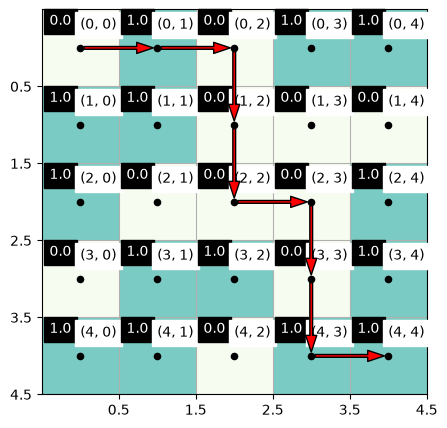

In [28]:
linha,coluna = grid.shape
fig, ax = plt.subplots(figsize=(linha,linha))
print(grid)
ax.imshow(grid,cmap='GnBu',vmin=0,vmax=2)
ax.grid(True)
ax.set_xticks(np.arange(0.5,coluna,1))
ax.set_yticks(np.arange(0.5,coluna,1))
# ax.invert_xaxis()  
# ax.invert_yaxis()  

for (i,j) in keys:

    # ax.text(j,i,grid[j,i],color='white',backgroundcolor='black')
    ax.text(j-0.4,i-0.3,grid[i,j],color='white',backgroundcolor='black')
    ax.text(j,i-0.25,(i,j),color='black',backgroundcolor='white',alpha=1)
    ax.scatter(j,i,marker='o',s=20,color='black')

for a,b,c,d in valores:
    print((a,b),"->",(c,d))
    ax.annotate("",xy=(d,c),xytext=(b,a),arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))

plt.show()